In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
from google.colab import files

uploaded = files.upload()

Saving co2_ml_ready.csv to co2_ml_ready.csv


In [3]:
df = pd.read_csv("co2_ml_ready.csv")

In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12225 entries, 0 to 12224
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         12225 non-null  object 
 1   year                            12225 non-null  int64  
 2   iso_code                        12225 non-null  object 
 3   population                      12225 non-null  float64
 4   gdp                             12225 non-null  float64
 5   energy_per_capita               12225 non-null  float64
 6   energy_per_gdp                  12225 non-null  float64
 7   primary_energy_consumption      12225 non-null  float64
 8   co2                             12225 non-null  float64
 9   co2_per_capita                  12225 non-null  float64
 10  co2_growth_abs                  12225 non-null  float64
 11  co2_growth_prct                 12225 non-null  float64
 12  co2_per_gdp                     

,year,population,gdp,energy_per_capita,energy_per_gdp,primary_energy_consumption,co2,co2_per_capita,co2_growth_abs,co2_growth_prct,...,cement_co2_per_capita,flaring_co2_per_capita,land_use_change_co2_per_capita,cumulative_co2,share_global_co2,total_ghg,methane,nitrous_oxide,temperature_change_from_co2,temperature_change_from_ghg
count,12225.000000,1.222500e+04,1.222500e+04,12225.000000,12225.000000,12225.000000,12225.000000,12225.000000,12225.000000,12225.000000,...,12225.000000,12225.000000,12225.000000,12225.000000,12225.000000,12150.000000,12150.000000,12150.000000,12225.000000,12225.000000
mean,1987.000000,3.118163e+07,2.968992e+11,22866.461993,1.625511,642.253956,128.708607,4.334945,2.626899,5.400367,...,0.105536,0.309623,2.403523,5027.645279,0.595265,222.301681,41.574236,12.612397,0.004077,0.005840
std,21.649596,1.150092e+08,1.211454e+12,32278.094627,1.508568,2562.192712,589.234657,6.889114,27.868921,16.157076,...,0.150006,3.066568,5.605721,24300.529416,2.533020,766.122423,115.794790,36.305123,0.015572,0.020097
min,1950.000000,2.430400e+04,4.998000e+07,0.000000,0.000000,0.000000,0.000000,0.000000,-545.958000,-33.333000,...,0.000000,0.000000,-9.652000,0.004000,0.000000,-7.583000,0.008000,0.002000,0.000000,-0.001000
25%,1968.000000,2.446752e+06,9.033098e+09,2177.473000,0.751000,15.477000,1.794000,0.366000,-0.048000,-1.341000,...,0.001000,0.000000,0.001000,25.395000,0.009000,14.266500,3.491250,1.001500,0.000000,0.000000
50%,1987.000000,6.778885e+06,3.314698e+10,10325.806000,1.213000,62.353000,9.831000,1.755000,0.115000,3.491000,...,0.052000,0.000000,0.629000,234.322000,0.051000,47.493500,10.209500,3.474000,0.001000,0.001000
75%,2006.000000,2.028430e+07,1.451925e+11,31098.662000,2.059000,326.212000,55.636000,6.076000,1.292000,9.091000,...,0.154000,0.046000,2.661000,1698.020000,0.252500,127.956000,29.310500,9.290500,0.002000,0.003000
max,2024.000000,1.450936e+09,2.696602e+13,318559.688000,25.253000,48987.102000,12289.037000,121.707000,910.106000,100.000000,...,1.490000,114.509000,81.469000,434866.562000,42.855000,14107.007000,1590.674000,475.534000,0.247000,0.296000


In [5]:
print("Rows, Columns:", df.shape)

Rows, Columns: (12225, 33)


In [6]:
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp', 'energy_per_capita',
       'energy_per_gdp', 'primary_energy_consumption', 'co2', 'co2_per_capita',
       'co2_growth_abs', 'co2_growth_prct', 'co2_per_gdp',
       'co2_per_unit_energy', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2',
       'flaring_co2', 'land_use_change_co2', 'coal_co2_per_capita',
       'oil_co2_per_capita', 'gas_co2_per_capita', 'cement_co2_per_capita',
       'flaring_co2_per_capita', 'land_use_change_co2_per_capita',
       'cumulative_co2', 'share_global_co2', 'total_ghg', 'methane',
       'nitrous_oxide', 'temperature_change_from_co2',
       'temperature_change_from_ghg'],
      dtype='object')

In [7]:
missing = df.isnull().sum()
missing[missing > 0]

,0
total_ghg,75
methane,75
nitrous_oxide,75


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
target = "co2_per_capita"

X = df.drop(columns=[target])
y = df[target]

In [14]:
X = X.fillna(X.median(numeric_only=True))

In [15]:
X.isnull().sum().sum()

np.int64(0)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
print(X_train.shape)
print(X_test.shape)

(9780, 354)
(2445, 354)


In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 :", r2_score(y_test, y_pred_lr))

MAE : 1.7693473176323404
RMSE : 3.5896460751668022
R2 : 0.7177697326333912


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [21]:
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 :", r2_score(y_test, y_pred_rf))

MAE : 0.19967561145194276
RMSE : 2.266341485452559
R2 : 0.8875003885501334


In [22]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [23]:
print("MAE :", mean_absolute_error(y_test, y_pred_gb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2 :", r2_score(y_test, y_pred_gb))

MAE : 0.39816423820758506
RMSE : 1.8359113655358485
R2 : 0.9261749506296744


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_sc, y_train)

y_pred_ridge = ridge.predict(X_test_sc)

In [25]:
!pip install xgboost

In [26]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)


In [27]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_xgb)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_xgb)
    ]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,RMSE,MAE
1,Ridge Regression,0.990190,0.669251,0.340147
3,Gradient Boosting,0.926175,1.835911,0.398164
2,Random Forest,0.887500,2.266341,0.199676
4,XGBoost,0.880692,2.333917,0.256160
0,Linear Regression,0.717770,3.589646,1.769347


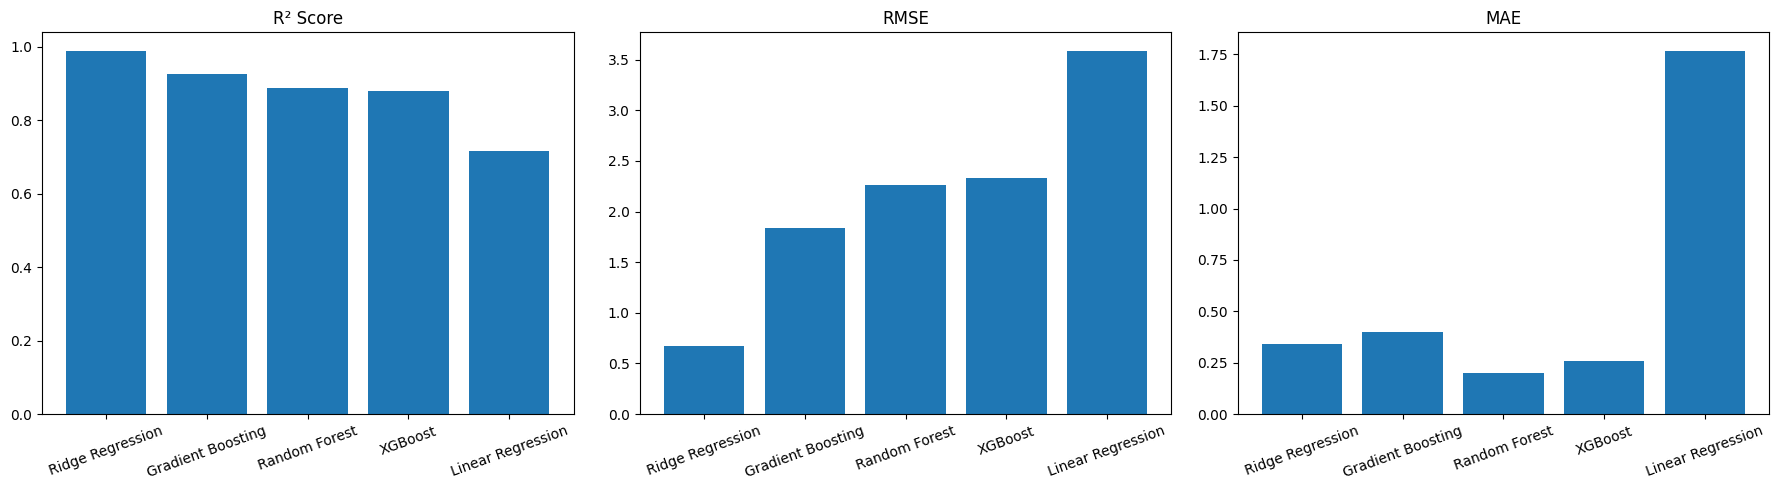

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# R²
axes[0].bar(results["Model"], results["R2 Score"])
axes[0].set_title("R² Score")
axes[0].tick_params(axis='x', rotation=20)

# RMSE
axes[1].bar(results["Model"], results["RMSE"])
axes[1].set_title("RMSE")
axes[1].tick_params(axis='x', rotation=20)

# MAE
axes[2].bar(results["Model"], results["MAE"])
axes[2].set_title("MAE")
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [40]:
best = results.iloc[0]

print("=" * 40)
print(f"🏆 Best Model : {best['Model']}")
print(f"R² Score     : {best['R2 Score']:.4f}")
print(f"RMSE         : {best['RMSE']:.4f}")
print(f"MAE          : {best['MAE']:.4f}")
print("=" * 40)

🏆 Best Model : Ridge Regression
R² Score     : 0.9902
RMSE         : 0.6693
MAE          : 0.3401


In [41]:
model_lookup = {
    "Linear Regression": lr,
    "Ridge Regression": ridge,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
}

best_model_name = best["Model"]
best_model = model_lookup[best_model_name]

joblib.dump(best_model, "best_model.pkl")

if best_model_name == "Ridge Regression":
    joblib.dump(scaler, "scaler.pkl")
    print("Saved best_model.pkl (Ridge) + scaler.pkl")
else:
    print(f"Saved best_model.pkl ({best_model_name})")

Saved best_model.pkl (Ridge) + scaler.pkl
